# Riesgo de sobrecarga vs congestion de calendario — CD Moquegua

Corre el pipeline completo (extract -> transform -> load) y deja **varias vistas de utilidad practica** para el cuerpo tecnico, no solo un ranking: estado actual del plantel, evolucion de ACWR en el tiempo, carga semanal por jugador, perfil de velocidad/sprint, carga mecanica (impactos y frenadas) y contexto de calendario. Pensado como paso `serve` para revisar resultados sin levantar Docker.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src.extract_gps import extract_all
from src.extract_fixtures import scrape_moquegua_calendar, fetch_brasileirao_fixtures
from src.transform_metrics import (
    validate_gps_data, compute_acwr, compute_congestion_index,
    compute_rest_days, build_risk_table,
)
from src.load_duckdb import get_connection, init_schema, load_dataframe

pd.set_option("display.max_rows", 60)

In [2]:
gps = extract_all()
gps["fecha"] = pd.to_datetime(gps["fecha"])
gps = validate_gps_data(gps)
print(f"{gps['dato_valido'].sum()} / {len(gps)} filas validas")

acwr = compute_acwr(gps[gps["dato_valido"]])

moquegua = scrape_moquegua_calendar()
moquegua["fecha"] = pd.to_datetime(moquegua["fecha"])
congestion_moquegua = compute_congestion_index(moquegua)

brasil = fetch_brasileirao_fixtures()
brasil["fecha"] = pd.to_datetime(brasil["fecha"])
congestion_brasil = compute_congestion_index(brasil)

risk_table = build_risk_table(acwr, congestion_moquegua)
risk_table.shape

2026-09-17 20:57:53,493 | INFO    | src.extract_gps | Extraidas 1128 filas jugador-sesion de 43 archivos (59 jugadores unicos)


2026-09-17 20:57:53,493 | INFO    | src.extract_gps | Distribucion por tipo de sesion: {'entrenamiento': 1086, 'amistoso': 27, 'oficial': 15}


1128 / 1128 filas validas


2026-09-17 20:57:54,031 | ERROR   | src.extract_fixtures | Scraping de Transfermarkt fallo (405 Client Error: Not Allowed for url: https://www.transfermarkt.com/ucv-moquegua/spielplandatum/verein/114625); usando snapshot cacheado


2026-09-17 20:57:54,045 | WARNING | src.extract_fixtures | FOOTBALL_DATA_API_KEY no configurada: usando fixtures mock de brasileirao_fixtures_mock.json


(1184, 11)

In [3]:
con = get_connection()
init_schema(con)

gps_out = gps.copy()
gps_out["fecha"] = gps_out["fecha"].dt.date
load_dataframe(con, gps_out, "gps_metrics")

risk_out = risk_table.copy()
risk_out["fecha"] = pd.to_datetime(risk_out["fecha"]).dt.date
load_dataframe(con, risk_out, "acwr_risk")

moquegua_rest = compute_rest_days(moquegua)
moquegua_rest_out = moquegua_rest.copy()
moquegua_rest_out["fecha"] = moquegua_rest_out["fecha"].dt.date
load_dataframe(con, moquegua_rest_out, "calendario_moquegua")

brasil_out = brasil.copy()
brasil_out["fecha"] = brasil_out["fecha"].dt.date
load_dataframe(con, brasil_out, "calendario_brasileirao")

load_dataframe(con, congestion_moquegua, "congestion_moquegua")
load_dataframe(con, congestion_brasil, "congestion_brasileirao")

2026-09-17 20:57:54,070 | INFO    | src.load_duckdb | Schema aplicado desde /Users/pauloncoy/Library/CloudStorage/OneDrive-Personal/05 Proyectos/Python/player-workload-risk/sql/schema.sql


2026-09-17 20:57:54,084 | INFO    | src.load_duckdb | Cargadas 1128 filas en gps_metrics


2026-09-17 20:57:54,090 | INFO    | src.load_duckdb | Cargadas 1184 filas en acwr_risk


2026-09-17 20:57:54,093 | INFO    | src.load_duckdb | Cargadas 31 filas en calendario_moquegua


2026-09-17 20:57:54,095 | INFO    | src.load_duckdb | Cargadas 20 filas en calendario_brasileirao


2026-09-17 20:57:54,097 | INFO    | src.load_duckdb | Cargadas 27 filas en congestion_moquegua


2026-09-17 20:57:54,098 | INFO    | src.load_duckdb | Cargadas 19 filas en congestion_brasileirao


## 1. Estado actual del plantel

Ultima sesion registrada de cada jugador: carga aguda (7d) vs cronica (28d), ACWR y bandera de riesgo. Esta es la tabla que se le mostraria al cuerpo tecnico antes de la sesion del dia.

In [4]:
estado_actual = con.execute(
    """
    WITH ultima_fecha AS (
        SELECT jugador, MAX(fecha) AS fecha FROM acwr_risk WHERE historia_suficiente GROUP BY jugador
    )
    SELECT r.jugador, r.fecha,
           ROUND(r.carga_aguda_7d, 1) AS carga_aguda_7d,
           ROUND(r.carga_cronica_28d, 1) AS carga_cronica_28d,
           ROUND(r.acwr, 2) AS acwr,
           r.riesgo_acwr
    FROM acwr_risk r
    JOIN ultima_fecha u ON r.jugador = u.jugador AND r.fecha = u.fecha
    ORDER BY r.acwr DESC
    """
).df()
print(f"{len(estado_actual)} jugadores con historia suficiente para ACWR ({estado_actual['riesgo_acwr'].sum()} en riesgo hoy)")
estado_actual

26 jugadores con historia suficiente para ACWR (1 en riesgo hoy)


,jugador,fecha,carga_aguda_7d,carga_cronica_28d,acwr,riesgo_acwr
0,Jugador_30,2026-01-17,180.6,117.0,1.54,True
1,Jugador_20,2026-01-17,256.1,259.6,0.99,False
2,Jugador_13,2026-01-17,190.1,194.7,0.98,False
3,Jugador_25,2026-01-17,254.8,261.1,0.98,False
4,Jugador_17,2026-01-17,230.7,237.2,0.97,False
5,Jugador_07,2026-01-17,247.4,259.5,0.95,False
6,Jugador_09,2026-01-17,247.8,261.0,0.95,False
7,Jugador_06,2026-01-17,248.7,265.8,0.94,False
8,Jugador_05,2026-01-17,248.1,268.1,0.93,False
9,Jugador_24,2026-01-17,253.4,275.9,0.92,False


## 2. Evolucion de ACWR en el tiempo (no solo el maximo)

El maximo historico esconde el contexto: ver la curva completa dice si el riesgo fue un pico aislado o una tendencia sostenida. Se grafican los jugadores que en algun momento cruzaron 1.3 (zona de alerta temprana, antes del umbral duro de 1.5).

Jugadores que cruzaron ACWR > 1.3 en algun momento: 1 -> ['Jugador_30']


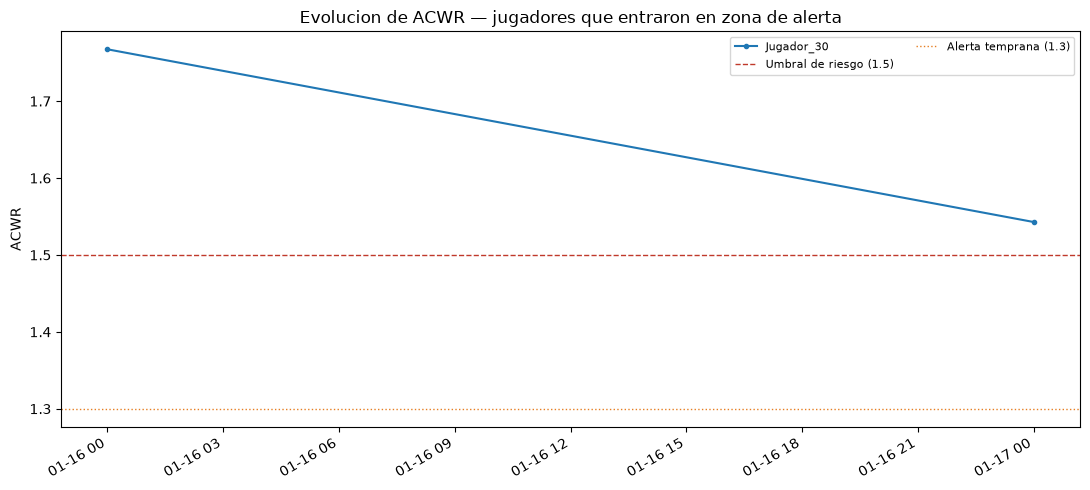

In [5]:
alerta_temprana = acwr[acwr["historia_suficiente"] & (acwr["acwr"] > 1.3)]["jugador"].unique()
print(f"Jugadores que cruzaron ACWR > 1.3 en algun momento: {len(alerta_temprana)} -> {list(alerta_temprana)}")

fig, ax = plt.subplots(figsize=(11, 5))
for jugador in alerta_temprana:
    serie = acwr[(acwr["jugador"] == jugador) & acwr["historia_suficiente"]].sort_values("fecha")
    ax.plot(serie["fecha"], serie["acwr"], marker="o", markersize=3, label=jugador)

ax.axhline(1.5, color="#c0392b", linestyle="--", linewidth=1, label="Umbral de riesgo (1.5)")
ax.axhline(1.3, color="#e67e22", linestyle=":", linewidth=1, label="Alerta temprana (1.3)")
ax.set_ylabel("ACWR")
ax.set_title("Evolucion de ACWR — jugadores que entraron en zona de alerta")
ax.legend(fontsize=8, ncol=2)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("../data/processed/acwr_evolucion.png", dpi=120)
plt.show()

## 3. Carga semanal del plantel completo (heatmap)

`player_load` sumado por jugador y semana. Sirve para dos cosas a la vez: detectar sobrecarga (filas muy oscuras sostenidas) y detectar **subcarga** — jugadores con semanas muy claras que capaz necesitan mas minutos, no menos.

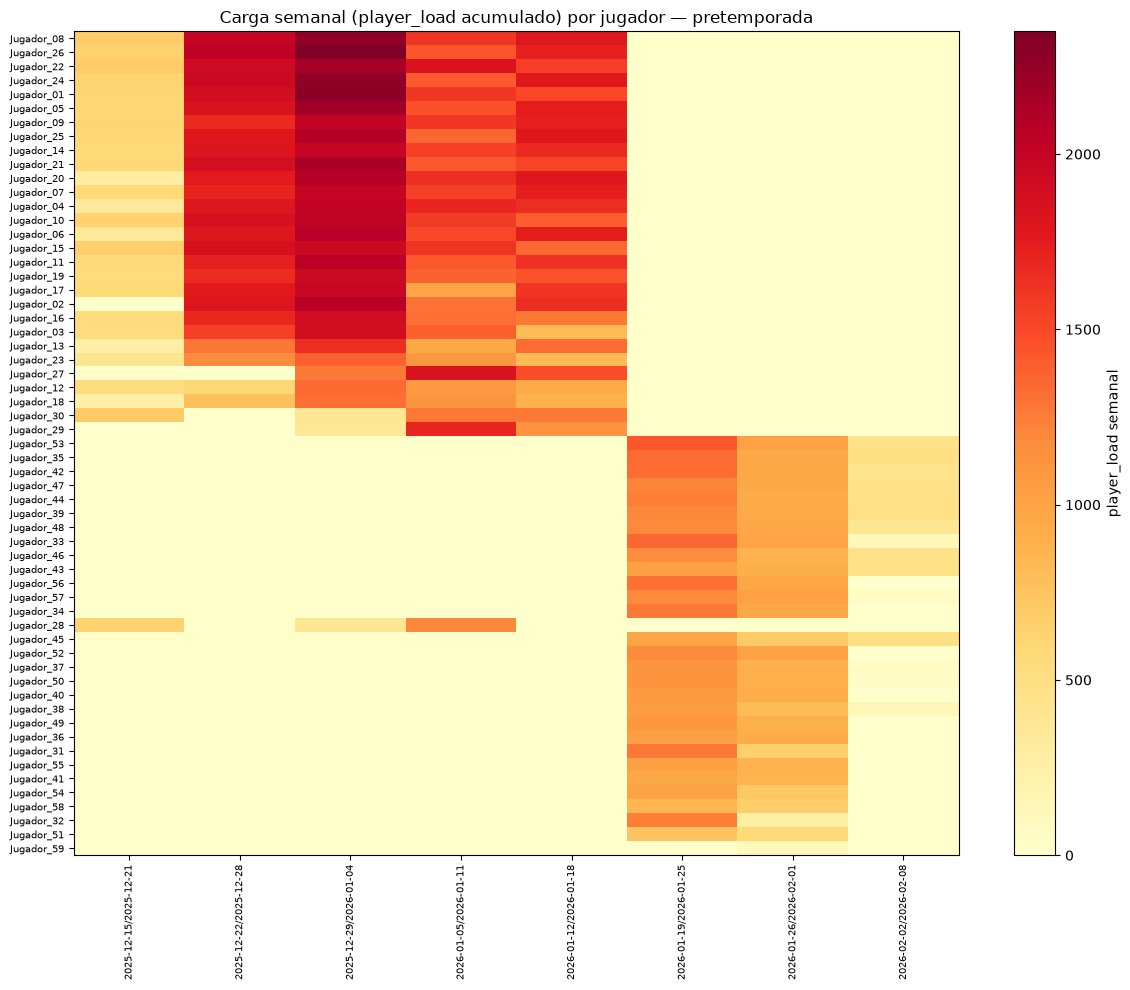

In [6]:
gps_valid = gps[gps["dato_valido"]].copy()
gps_valid["semana"] = gps_valid["fecha"].dt.to_period("W").astype(str)

pivot = gps_valid.pivot_table(index="jugador", columns="semana", values="player_load", aggfunc="sum", fill_value=0)
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=7, rotation=90)
ax.set_title("Carga semanal (player_load acumulado) por jugador — pretemporada")
fig.colorbar(im, ax=ax, label="player_load semanal")
plt.tight_layout()
plt.savefig("../data/processed/heatmap_carga_semanal.png", dpi=120)
plt.show()

## 4. Perfil fisico: volumen total vs. acciones explosivas

Dos senales genuinamente distintas: volumen total (trabajo aerobico sostenido) vs. distancia de sprint (acciones explosivas puntuales). **Nota de calidad de dato**: en este export, `distancia_alta_velocidad_m` (zona 4-5 de Catapult) resulto ser practicamente identica a `distancia_sprint_m` (correlacion 0.9999998) porque el club configuro el umbral de sprint igual al piso de zona 4 — por eso no se usa como tercer panel, seria informacion duplicada disfrazada de insight nuevo.

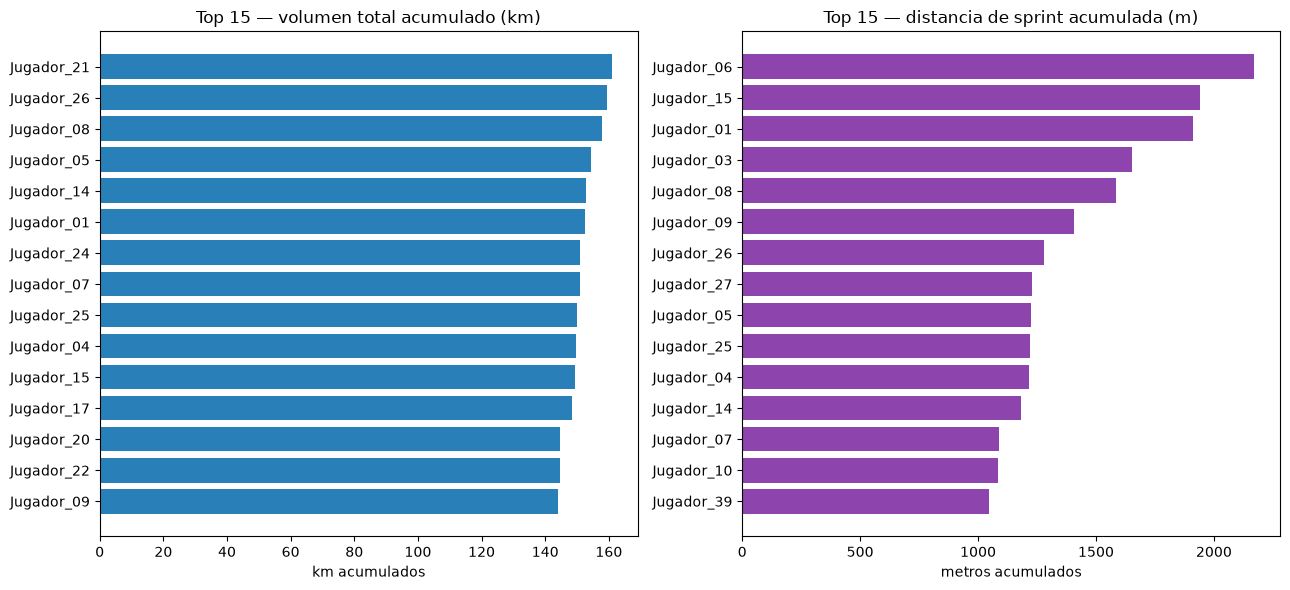

Jugadores que aparecen en ambos top-15 (volumen Y sprint): 10 de 15


In [7]:
resumen_jugador = gps_valid.groupby("jugador").agg(
    distancia_total_m=("distancia_total_m", "sum"),
    distancia_sprint_m=("distancia_sprint_m", "sum"),
    sesiones=("fecha", "nunique"),
).reset_index()
resumen_jugador["distancia_total_km_por_sesion"] = (resumen_jugador["distancia_total_m"] / resumen_jugador["sesiones"]) / 1000

top_volumen = resumen_jugador.nlargest(15, "distancia_total_m")
top_sprint = resumen_jugador.nlargest(15, "distancia_sprint_m")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(top_volumen["jugador"], top_volumen["distancia_total_m"] / 1000, color="#2980b9")
axes[0].invert_yaxis()
axes[0].set_xlabel("km acumulados")
axes[0].set_title("Top 15 — volumen total acumulado (km)")

axes[1].barh(top_sprint["jugador"], top_sprint["distancia_sprint_m"], color="#8e44ad")
axes[1].invert_yaxis()
axes[1].set_xlabel("metros acumulados")
axes[1].set_title("Top 15 — distancia de sprint acumulada (m)")

plt.tight_layout()
plt.savefig("../data/processed/ranking_volumen_sprint.png", dpi=120)
plt.show()

solapamiento = len(set(top_volumen["jugador"]) & set(top_sprint["jugador"]))
print(f"Jugadores que aparecen en ambos top-15 (volumen Y sprint): {solapamiento} de 15")

## 5. Carga mecanica: impactos y frenadas/arranques bruscos

El ACWR mide volumen de carga, no impacto mecanico. Un jugador con ACWR normal puede igual estar acumulando muchas frenadas/arranques fuertes (tipicamente asociado a sobrecarga de tejido blando — isquios, aductores) o muchos impactos (choques, caidas). Se identifican outliers con z-score sobre el promedio del plantel.

In [8]:
carga_mecanica = gps_valid.groupby("jugador").agg(
    impactos_totales=("impactos", "sum"),
    aceleracion_max_prom=("aceleracion_max", "mean"),
    desaceleracion_max_prom=("desaceleracion_max", "mean"),
    sesiones=("fecha", "nunique"),
).reset_index()

for col in ["impactos_totales", "aceleracion_max_prom", "desaceleracion_max_prom"]:
    z = (carga_mecanica[col] - carga_mecanica[col].mean()) / carga_mecanica[col].std()
    carga_mecanica[f"z_{col}"] = z.round(2)

outliers_mecanicos = carga_mecanica[
    (carga_mecanica["z_impactos_totales"] > 1.5)
    | (carga_mecanica["z_desaceleracion_max_prom"] > 1.5)
].sort_values("z_desaceleracion_max_prom", ascending=False)

print(f"{len(outliers_mecanicos)} jugadores con carga mecanica atipica (z-score > 1.5 en impactos o frenadas):")
outliers_mecanicos[["jugador", "impactos_totales", "z_impactos_totales", "desaceleracion_max_prom", "z_desaceleracion_max_prom"]]

7 jugadores con carga mecanica atipica (z-score > 1.5 en impactos o frenadas):


,jugador,impactos_totales,z_impactos_totales,desaceleracion_max_prom,z_desaceleracion_max_prom
57,Jugador_58,56,0.25,7.522200,2.63
11,Jugador_12,146,2.23,7.087571,1.82
56,Jugador_57,21,-0.52,6.961050,1.58
12,Jugador_13,145,2.21,6.610270,0.93
26,Jugador_27,188,3.16,6.424274,0.58
17,Jugador_18,146,2.23,6.257275,0.27
21,Jugador_22,165,2.65,6.247781,0.25


## 6. Congestion de calendario: Moquegua vs Brasileirao (contexto)

Partidos por semana e indice de congestion de CD Moquegua a lo largo de la temporada 2026, comparado contra el promedio del Brasileirao Serie A. Recordatorio: el Brasileirao **no aporta datos fisicos**, solo referencia de que tan apretado puede llegar a estar un calendario de liga grande.

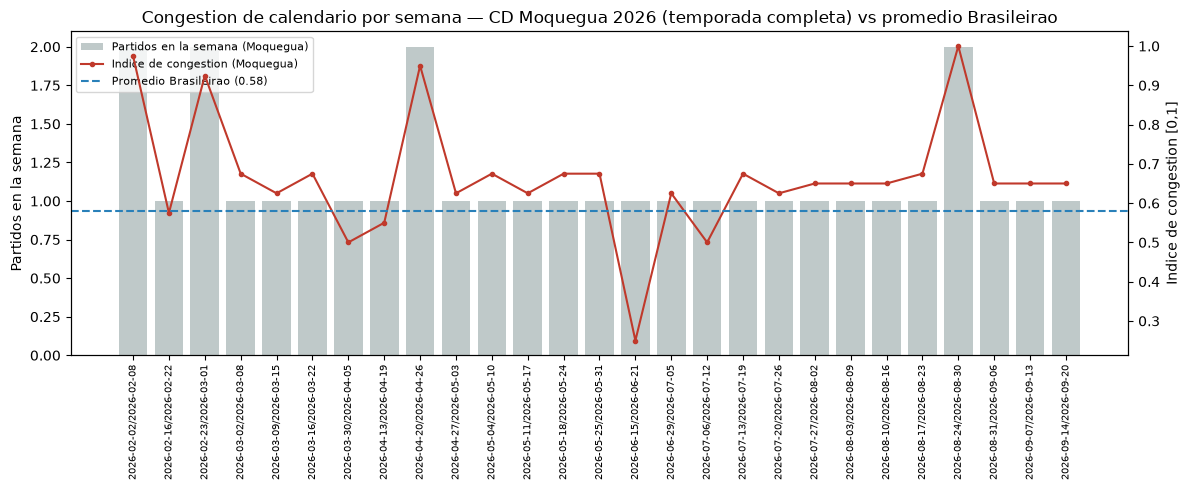

Congestion promedio Moquegua: 0.67  |  Brasileirao: 0.58


In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))
x = range(len(congestion_moquegua))
ax1.bar(x, congestion_moquegua["partidos_semana"], color="#95a5a6", alpha=0.6, label="Partidos en la semana (Moquegua)")
ax1.set_xticks(x)
ax1.set_xticklabels(congestion_moquegua["semana"], rotation=90, fontsize=7)
ax1.set_ylabel("Partidos en la semana")

ax2 = ax1.twinx()
ax2.plot(x, congestion_moquegua["indice_congestion"], color="#c0392b", marker="o", markersize=3, label="Indice de congestion (Moquegua)")
ax2.axhline(congestion_brasil["indice_congestion"].mean(), color="#2980b9", linestyle="--",
            label=f"Promedio Brasileirao ({congestion_brasil['indice_congestion'].mean():.2f})")
ax2.set_ylabel("Indice de congestion [0,1]")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax1.set_title("Congestion de calendario por semana — CD Moquegua 2026 (temporada completa) vs promedio Brasileirao")
plt.tight_layout()
plt.savefig("../data/processed/congestion_calendario.png", dpi=120)
plt.show()

print(f"Congestion promedio Moquegua: {congestion_moquegua['indice_congestion'].mean():.2f}  |  Brasileirao: {congestion_brasil['indice_congestion'].mean():.2f}")

## 7. Resumen ejecutivo (generado con los numeros reales de esta corrida)

In [10]:
acwr_confiable = acwr[acwr["historia_suficiente"]]

n_jugadores = gps_valid["jugador"].nunique()
n_riesgo_historico = acwr_confiable[acwr_confiable["acwr"] > 1.5]["jugador"].nunique()
n_alerta_temprana = len(alerta_temprana)
jugador_max = acwr_confiable.loc[acwr_confiable["acwr"].idxmax()]

resumen = f"""
- **{n_jugadores} jugadores** con datos GPS validos en pretemporada (dic 2025 - feb 2026), de los cuales **{len(acwr_confiable['jugador'].unique())}** acumularon los 28 dias de historia necesarios para que su ACWR sea confiable (el resto son jugadores de la segunda ventana de roster, con menos de 28 dias de datos: ver limitaciones).
- **{n_riesgo_historico} jugador(es)** cruzo el umbral de riesgo duro (ACWR > 1.5) en algun momento **con historia suficiente**: {list(acwr_confiable[acwr_confiable['acwr']>1.5]['jugador'].unique())}.
- **{n_alerta_temprana} jugador(es)** entraron en zona de alerta temprana (ACWR > 1.3), con historia suficiente.
- Pico maximo confiable observado: **{jugador_max['jugador']}** con ACWR **{jugador_max['acwr']:.2f}** el {jugador_max['fecha'].date()} (excluye jugadores con historia_suficiente=False, cuyo ACWR puede estar inflado por un denominador cronico incompleto — ej. Jugador_28 llega a un ACWR de 2.25 con solo 22 dias de datos, no confiable, deliberadamente fuera de este numero).
- **{len(outliers_mecanicos)} jugador(es)** con carga mecanica atipica (impactos o frenadas por fuera de lo normal del plantel), independiente del ACWR — candidatos a revisión aunque su carga de volumen este dentro de rango.
- Congestion de calendario Moquegua 2026: promedio **{congestion_moquegua['indice_congestion'].mean():.2f}** vs Brasileirao **{congestion_brasil['indice_congestion'].mean():.2f}** (referencia, no consecuencia directa sobre estos jugadores en esta ventana de pretemporada).
"""
display(Markdown(resumen))


- **59 jugadores** con datos GPS validos en pretemporada (dic 2025 - feb 2026), de los cuales **26** acumularon los 28 dias de historia necesarios para que su ACWR sea confiable (el resto son jugadores de la segunda ventana de roster, con menos de 28 dias de datos: ver limitaciones).
- **1 jugador(es)** cruzo el umbral de riesgo duro (ACWR > 1.5) en algun momento **con historia suficiente**: ['Jugador_30'].
- **1 jugador(es)** entraron en zona de alerta temprana (ACWR > 1.3), con historia suficiente.
- Pico maximo confiable observado: **Jugador_30** con ACWR **1.77** el 2026-01-16 (excluye jugadores con historia_suficiente=False, cuyo ACWR puede estar inflado por un denominador cronico incompleto — ej. Jugador_28 llega a un ACWR de 2.25 con solo 22 dias de datos, no confiable, deliberadamente fuera de este numero).
- **7 jugador(es)** con carga mecanica atipica (impactos o frenadas por fuera de lo normal del plantel), independiente del ACWR — candidatos a revisión aunque su carga de volumen este dentro de rango.
- Congestion de calendario Moquegua 2026: promedio **0.67** vs Brasileirao **0.58** (referencia, no consecuencia directa sobre estos jugadores en esta ventana de pretemporada).


## Limitaciones de esta corrida

- El snapshot de GPS es pretemporada (dic 2025 - ene/feb 2026); la Liga 1 Apertura recien arranca el 02/02/2026, por lo que las semanas de entrenamiento analizadas no se solapan con semanas de partidos. En esta corrida especifica `alerta_combinada` puede dar 0 casos aunque `riesgo_acwr` si detecte jugadores — la logica del flag combinado esta cubierta por tests unitarios y se activaria con datos de una temporada en curso.
- El roster tiene una discontinuidad de nomenclatura de jugador entre el 17 y el 20 de enero de 2026: los codigos anonimizados no se mezclan entre ambas convenciones, asi que el ACWR de jugadores que solo aparecen en la segunda ventana parte con menos historial (por eso la seccion 1 solo muestra jugadores con `historia_suficiente`).
- `num_sprints` no existe en el export de Catapult confirmado; se omitio en vez de aproximarlo con una metrica inventada.
- Los umbrales de z-score de carga mecanica (seccion 5) son relativos al propio plantel en esta ventana, no valores clinicos absolutos — sirven para priorizar revision, no como diagnostico.
- Es un pipeline batch sobre datos historicos, no una integracion en vivo con Catapult ni con el club.